In [1]:
%load_ext autoreload
%autoreload 2

import scipy
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
import pandas as pd

from rule_generation_utils import *
from toy_example_utils import *
from geometric_rule_distance import *
from rulesetparsing import *
from utils import *

import time
import os

# **Toy Experiment settings**

In [239]:
test_ID = "GapRules2"
res_path = "test_rulesim_custom_GIoU/"
os.makedirs(res_path, exist_ok=True)
ruleset_save_path = res_path+f"synthetic_{test_ID}.csv"

rulesim_path = res_path + f"rulesim_{test_ID}"

save_plots_flag = True
if save_plots_flag:
    os.makedirs(res_path+"/plots/", exist_ok=True)
# file for custom dataset (uniform sampling within the rules)    
outfile = res_path + f"data_{test_ID}.xlsx"


## 1) Custom Rule Generation

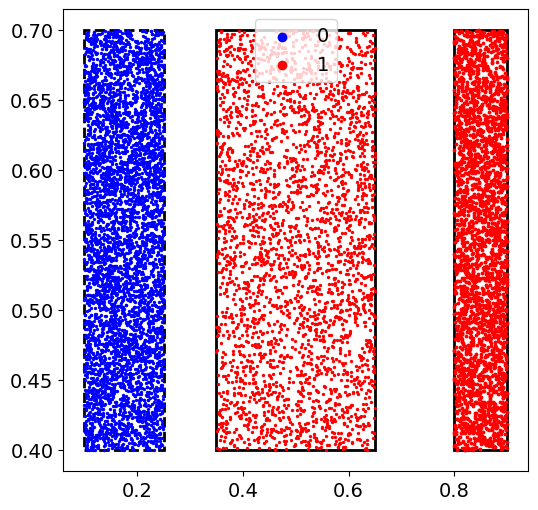

In [ ]:

###### DT1 case #######
if test_ID == "DT1":
    # Rule 1
    l11, u11 = 0.1, 0.7
    l21, u21 = 0.25, 0.9
    y1 = 0
    # Rule 2
    l12, u12 = 0.1, 0.7
    l22, u22 = 0.1, 0.25
    y2 = 1
    # Rule 3
    l13, u13 = 0.7, 0.9
    l23, u23 = 0.1, 0.9
    y3 = 1
    changeclsidx = 2
##########################
if test_ID == "DT2":
    # Rule 1
    l11, u11 = 0.1, 0.3
    l21, u21 = 0.4, 0.7
    y1 = 0
    # Rule 2
    l12, u12 = 0.3, 0.5
    l22, u22 = 0.4, 0.7
    y2 = 1
    # Rule 3
    l13, u13 = 0.5, 0.8
    l23, u23 = 0.4, 0.7
    y3 = 1
    changeclsidx = 2
if test_ID == "DT3":
    # Rule 1
    l11, u11 = 0.1, 0.3
    l21, u21 = 0.4, 0.7
    y1 = 0
    # Rule 2
    l12, u12 = 0.5, 0.8
    l22, u22 = 0.4, 0.7
    y2 = 0
    # Rule 3
    l13, u13 = 0.3, 0.5
    l23, u23 = 0.4, 0.7
    y3 = 1
    changeclsidx = 3
if test_ID == "GapRules":
    # Rule 1
    l11, u11 = 0.1, 0.25
    l21, u21 = 0.4, 0.7
    y1 = 0
    # Rule 2
    l12, u12 = 0.8, 0.9
    l22, u22 = 0.4, 0.7
    y2 = 0
    # Rule 3
    l13, u13 = 0.35, 0.65
    l23, u23 = 0.4, 0.7
    y3 = 1
    changeclsidx = 3

if test_ID == "GapRules2":
    # Rule 1
    l11, u11 = 0.1, 0.25
    l21, u21 = 0.4, 0.7
    y1 = 0
    # Rule 2
    l12, u12 = 0.35, 0.65
    l22, u22 = 0.4, 0.7
    y2 = 1
    # Rule 3
    l13, u13 = 0.8, 0.9
    l23, u23 = 0.4, 0.7
    y3 = 1
    changeclsidx = 2

# same examples as PR paper
if test_ID == "adjacent_case_PR":
    # Cambia le soglie!!!
    #rule 1 (y = 0)
    l11, u11 = 0.07, 0.27
    l21, u21 = 0.6, 1
    y1 = 0

    # rule 2
    l12, u12 = 0.27, 0.8
    l22, u22 = 0.4, 0.75
    y2 = 1

    # rule 3
    l13, u13 = 0.8, 1.1
    l23, u23 = 0.24, 0.55
    y3 = 1

scatter_colors = {0: "b", 1: "r"}
scatter_style = {0: "--", 1: "-"}

rule_info = [[l11, u11, l21, u21, y1], [l12, u12, l22, u22, y2], [l13, u13, l23, u23, y3]]
write_and_save_ruleset(rule_info, save_path = ruleset_save_path)
# Set random seed
np.random.seed(102)

# Generate random points for each rule
R1, w1, h1 = get_rule_points(l11, u11, l21, u21, 5000)
R2, w2, h2 = get_rule_points(l12, u12, l22, u22, 3000)
R3, w3, h3 = get_rule_points(l13, u13, l23, u23, 3000)

fig, ax = plt.subplots(figsize=(6, 6))
ax.add_patch(plt.Rectangle((l11, l21), w1, h1, linewidth=2, linestyle = scatter_style[y1], edgecolor='black', facecolor='none'))
ax.add_patch(plt.Rectangle((l12, l22), w2, h2, linewidth=2, linestyle = scatter_style[y2], edgecolor='black', facecolor='none'))
ax.add_patch(plt.Rectangle((l13, l23), w3, h3, linewidth=2, linestyle = scatter_style[y3], edgecolor='black', facecolor='none'))

s1 = ax.scatter(R1[:, 0], R1[:, 1], s=2, c=scatter_colors[y1])
s2 = ax.scatter(R2[:, 0], R2[:, 1], s=2, c=scatter_colors[y2])
ax.scatter(R3[:, 0], R3[:, 1], s=3, c=scatter_colors[y3]) 


ax.scatter([], [], c='b', label="0")
ax.scatter([], [], c='r', label="1")

ax.legend(fontsize=14)
#ax.set_xlim([0,1])
#ax.set_ylim([0,1])

#ax.legend(fontsize=14)
ax.tick_params(labelsize=14)
if save_plots_flag:
    plt.savefig(res_path+f"plots/synthetic_classes_{test_ID}.png", dpi = 200, bbox_inches="tight")
plt.show()

# **Data preparation**
Split training, calibration and test sets

In [241]:

data = np.vstack([np.column_stack([R1, np.zeros((len(R1),1))]), np.column_stack([R2, np.ones((len(R2),1))]), np.column_stack([R3, np.ones((len(R3),1))])])
dt = pd.DataFrame(data,columns=['X1','X2','output'])

dt.to_excel(outfile, index = False)

In [242]:
#data = pd.read_excel("toy_example_dt/data_toyex_close.xlsx")

data_train_cal, data_ts = train_test_split(dt, test_size=2000, random_state=102)

data_tr, data_cal = train_test_split(data_train_cal, test_size=5000, random_state=102)



# Rule thresholds
rule_limits = np.array([[l11, u11, l21, u21], [l12, u12, l22, u22], [l13, u13, l23, u23]])

# Index of the first rule of class 1

nrules = rule_limits.shape[0]


relevance = np.zeros(nrules)


Xts = data_ts.iloc[:, [0, 1]].to_numpy()
Yts = data_ts.iloc[:, 2].to_numpy()

Xcal = data_cal.iloc[:, [0, 1]].to_numpy()
Ycal = data_cal.iloc[:, 2].to_numpy()

n_c = Xcal.shape[0]


# **Compute rule similarity**

In [243]:
# now loaded from external file, but could be integrated here
# rulesim = pd.read_excel(rulesim_path, index_col=0)
# rulesim = rulesim.to_numpy()  # Convert to numpy array

# parse the ruleset to extract each condition and fill each rule with missing thresholds
parsedruleset = clean_ruleset_file(ruleset_save_path, dt, ["X1", "X2"], 2, "output")
parsedruleset.Feature = parsedruleset.Feature.astype("category")
parsedruleset.Feature = parsedruleset.Feature.cat.set_categories(["X1", "X2"])
parsedruleset = parsedruleset.sort_values(["Rule ID", "Feature"])

# compute geometric rule similarity
#rulesim, rule_dist, aggregated_mat = UnifiedRuleSimilarity(parsedruleset,ruleset_save_path, alpha=1.0, AREA=True, SAVE_RS_VALUES=False, save_path=res_path+"unified_rulesim_close_alpha1.0")#HyperRectDistance(parsedruleset, rulesetfile, SAVE_RS_VALUES=True, save_path="ruledist_far")
#print(rulesim)
#print(rule_dist)
#print(aggregated_mat)

rulesim = GeneralizedIoU(parsedruleset, rulesetfile=ruleset_save_path, SAVE_RS_VALUES=True, save_path=rulesim_path) #RuleSimilarity(parsedruleset, rulesetfile=ruleset_save_path, SAVE_RS_VALUES=True, save_path=rulesim_path)
rulesim


array([[1.        , 0.40909091, 0.15625   ],
       [0.40909091, 1.        , 0.36363636],
       [0.15625   , 0.36363636, 1.        ]])

# **Perform conformal prediction pipeline**

# Compute calibration scores

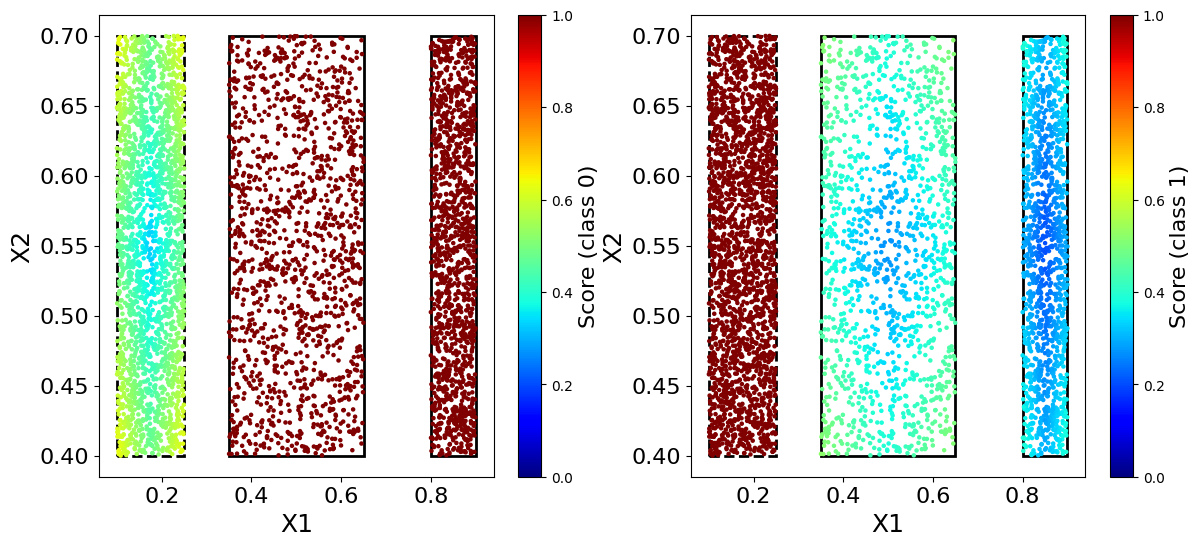

In [244]:
from matplotlib import colors

tau0low, Scal = compute_dataset_score(Xcal, rulesim, rule_limits, changeclsidx, 0, relevance)
tau1low, _ = compute_dataset_score(Xcal, rulesim, rule_limits, changeclsidx, 1, relevance)

norm = colors.Normalize(vmin=0, vmax=1)

# Plotting for tau0low
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14, 6))

ax1.add_patch(plt.Rectangle((l11, l21), w1, h1, linewidth=2, linestyle = scatter_style[y1], edgecolor='black', facecolor='none'))
ax1.add_patch(plt.Rectangle((l12, l22), w2, h2, linewidth=2, linestyle = scatter_style[y2], edgecolor='black', facecolor='none'))
ax1.add_patch(plt.Rectangle((l13, l23), w3, h3, linewidth=2, linestyle = scatter_style[y3], edgecolor='black', facecolor='none'))

sc = ax1.scatter(Xcal[:, 0], Xcal[:, 1], c=tau0low, s=5, cmap='jet', marker='o',norm = norm)

cbar = plt.colorbar(sc, ax=ax1)
cbar.set_label('Score (class 0)', fontsize=16)
#cbar.set_ticks([0, 1])
#cbar.set_ticklabels(['0.0', '1.0'])
ax1.set_xlabel("X1", fontsize=18)
ax1.set_ylabel("X2", fontsize=18)
#ax1.set_xlim([0,1])
#ax1.set_ylim([0,1])
ax1.tick_params(labelsize=16)

ax2.add_patch(plt.Rectangle((l11, l21), w1, h1, linewidth=2, linestyle = scatter_style[y1], edgecolor='black', facecolor='none'))
ax2.add_patch(plt.Rectangle((l12, l22), w2, h2, linewidth=2, linestyle = scatter_style[y2], edgecolor='black', facecolor='none'))
ax2.add_patch(plt.Rectangle((l13, l23), w3, h3, linewidth=2, linestyle = scatter_style[y3], edgecolor='black', facecolor='none'))

sc = ax2.scatter(Xcal[:, 0], Xcal[:, 1], c=tau1low, s=5, cmap='jet', marker='o', norm = norm)

cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label('Score (class 1)', fontsize=16)

ax2.set_xlabel("X1", fontsize=18)
ax2.set_ylabel("X2", fontsize=18)
#ax2.set_xlim([0,1])
#ax2.set_ylim([0,1])
ax2.tick_params(labelsize=16)
if save_plots_flag:
    plt.savefig(res_path+f"plots/scores_calib_{test_ID}.png", dpi = 200, bbox_inches="tight")
plt.show()


# Get prediction sets and evaluate

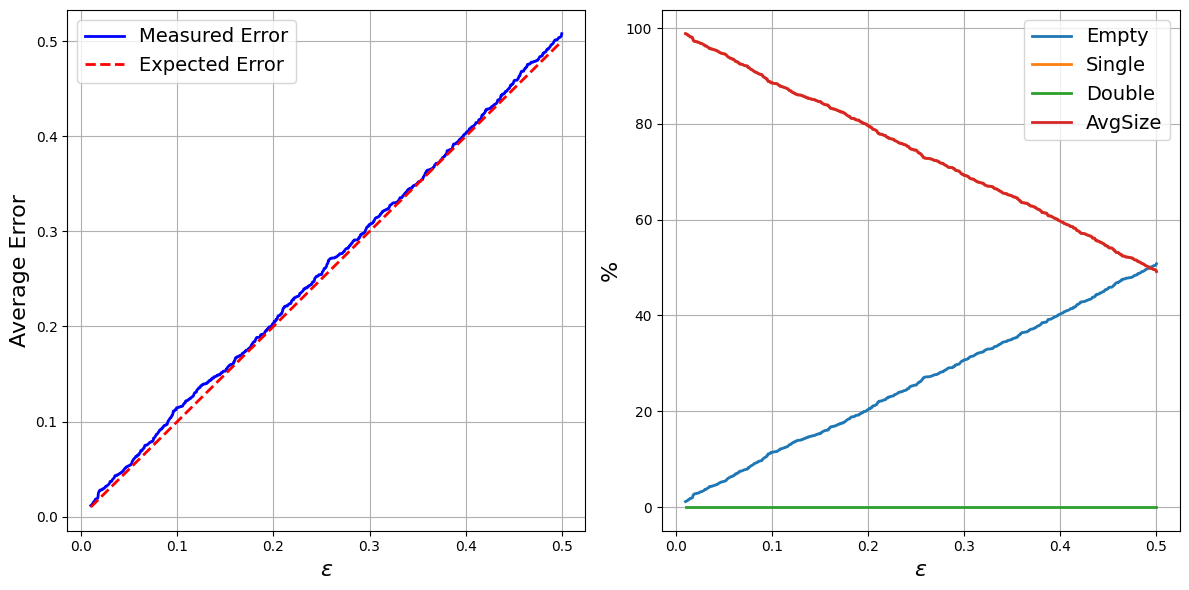

In [245]:
from collections import Counter

tau0ts, Sts = compute_dataset_score(Xts, rulesim, rule_limits, changeclsidx, 0, relevance)
tau1ts, _ = compute_dataset_score(Xts, rulesim, rule_limits, changeclsidx, 1, relevance)

epsilonrange = np.linspace(0.01, 0.5, 1000)
n_eps = len(epsilonrange)

avgErr = np.zeros(n_eps)
empty = np.zeros(n_eps)
singleton = np.zeros(n_eps)
double = np.zeros(n_eps)
avgSize = np.zeros(n_eps)
for i, epsilon in enumerate(epsilonrange):
    # Compute prediction regions
    C_all, s_epsilon, selectedscores, C_size = GetPredictionRegions(Ycal, tau0low, tau1low, tau0ts, tau1ts, epsilon, n_c)
    #print(Counter(C_size))
    n_err = np.sum((Yts != C_all) & (C_all != 2))
    avgErr[i] = n_err / len(Xts)
    
    empty[i] = np.sum(C_size == 0) / len(Xts)
    singleton[i] = np.sum(C_size == 1) / len(Xts)
    double[i] = np.sum(C_size == 2) / len(Xts)

    avgSize[i] = np.sum(C_size)/len(Xts)
    #print("avgSize: ",  np.sum(C_size)/len(Xts))

# Plot with subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))


axs[0].plot(epsilonrange, avgErr, 'b', linewidth=2, label='Measured Error')
axs[0].plot(epsilonrange, epsilonrange, 'r--', linewidth=2, label='Expected Error')
axs[0].set_xlabel(r'$\varepsilon$', fontsize=16)
axs[0].set_ylabel("Average Error", fontsize=16)
axs[0].legend(fontsize=14)
axs[0].grid(True)


axs[1].plot(epsilonrange, empty * 100, linewidth=2, label='Empty')
axs[1].plot(epsilonrange, singleton * 100, linewidth=2, label='Single')
axs[1].plot(epsilonrange, double * 100, linewidth=2, label='Double')
axs[1].plot(epsilonrange, avgSize * 100, linewidth=2, label='AvgSize')
axs[1].set_xlabel(r'$\varepsilon$', fontsize=16)
axs[1].set_ylabel("%", fontsize=16)
axs[1].legend(fontsize=14)
axs[1].grid(True)
if save_plots_flag:
    plt.savefig(res_path+f"plots/evaluation_metrics_{test_ID}.png", dpi = 200, bbox_inches="tight")
plt.tight_layout()
plt.show()